In [9]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import kaggle 

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi
import os

# Mostra onde o Kaggle está procurando o arquivo (útil para debug)
print("Caminho esperado para kaggle.json:", os.path.expanduser('~/.kaggle/kaggle.json'))

api = KaggleApi()
try:
    api.authenticate()
    print("✅ Autenticação SUCESSO! Você está conectado à API do Kaggle.")
    
    # Teste extra: lista datasets para confirmar
    datasets = api.dataset_list(search='fraud-detection', max_size=10)
    print("\nExemplo de datasets encontrados:")
    for ds in datasets[:3]:
        print(f"- {ds.ref} ({ds.title})")
except Exception as e:
    print("Erro na autenticação:", str(e))

Caminho esperado para kaggle.json: C:\Users\Jp Lima/.kaggle/kaggle.json
✅ Autenticação SUCESSO! Você está conectado à API do Kaggle.

Exemplo de datasets encontrados:
- tiennguyen143/data-fraud-detection (Data Fraud Detection)
- userabc12541874/audit-data (AUDIT_DATA)
- narendrabariha/credit-card-fraud-transaction-detection (Credit Card Fraud Transaction Detection)


In [5]:
# ================================================
# CÉLULA PARA CRIAR PASTAS + BAIXAR VIA KAGGLE API
# ================================================

from pathlib import Path   # Importa a classe correta
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

print("pathlib.Path importado OK → tipo:", type(Path))

# Diretório raiz do projeto (ajuste se necessário)
# Opção 1: relativo ao diretório atual do notebook
project_root = Path.cwd().parent   # vai para fraud_detection (pasta pai de notebooks)

# Opção 2: caminho absoluto fixo (use se a opção 1 não funcionar)
# project_root = Path(r"C:\Users\Jp Lima\Desktop\fraud_detection\fraud_detection")

print("Diretório raiz do projeto:", project_root.resolve())

if not project_root.exists():
    print("Aviso: pasta raiz não encontrada. Verifique o caminho.")
else:
    print("Pasta raiz encontrada!")

# Criação das pastas
folders = [
    'data/raw',
    'data/processed',
    'notebooks',
    'src/data_prep',
    'src/features',
    'src/models',
    'src/utils',
    'config',
    'outputs',
    'app',
    '.github/workflows'
]

for folder in folders:
    full_path = project_root / folder
    full_path.mkdir(parents=True, exist_ok=True)

print("Estrutura de pastas criada/confirmada!")

# ====================== DOWNLOAD VIA API ======================
try:
    api = KaggleApi()
    api.authenticate()
    print("Autenticação Kaggle OK!")

    dataset = "kartik2112/fraud-detection"
    download_dir = project_root / 'data' / 'raw'

    print(f"Baixando dataset '{dataset}' para: {download_dir}")
    api.dataset_download_files(dataset, path=download_dir, unzip=False)

    # Extrai o ZIP automaticamente
    zip_path = next(download_dir.glob("*.zip"), None)
    if zip_path:
        print(f"Extraindo {zip_path.name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(download_dir)
        zip_path.unlink()  # remove o ZIP após extrair
        print("Download + extração concluídos!")
    else:
        print("Download feito, mas nenhum .zip encontrado para extrair.")

except Exception as e:
    print("Erro durante download/autenticação:")
    print(str(e))
    print("\nDicas rápidas:")
    print("1. Verifique se kaggle.json está em: C:\\Users\\Jp Lima\\.kaggle\\kaggle.json")
    print("2. Gere novo token em: https://www.kaggle.com/settings/account → API → Create New Token")
    print("3. Ou baixe manualmente: https://www.kaggle.com/datasets/kartik2112/fraud-detection")

pathlib.Path importado OK → tipo: <class 'type'>
Diretório raiz do projeto: C:\Users\Jp Lima\Desktop\fraud_detection\fraud_detection
Pasta raiz encontrada!
Estrutura de pastas criada/confirmada!
Autenticação Kaggle OK!
Baixando dataset 'kartik2112/fraud-detection' para: c:\Users\Jp Lima\Desktop\fraud_detection\fraud_detection\data\raw
Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection
Extraindo fraud-detection.zip...
Download + extração concluídos!


In [6]:
df = pd.read_csv(r"C:\Users\Jp Lima\Desktop\fraud_detection\fraud_detection\data\raw\fraudTrain.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [7]:
# ======================== 2. VISÃO GERAL DOS DADOS ========================
print("=== INFO GERAL ===")
df.info()

print("\n=== 5 primeiras linhas ===")
display(df.head())

print("\n=== Valores nulos ===")
print(df.isnull().sum().sum())  # Deve ser 0

print("\n=== Duplicatas ===")
print(df.duplicated().sum())   # Normalmente 0

# Coluna inútil
df.drop(columns=['Unnamed: 0'], inplace=True)
print("Coluna 'Unnamed: 0' removida.")

=== INFO GERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14 

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



=== Valores nulos ===
0

=== Duplicatas ===
0
Coluna 'Unnamed: 0' removida.


=== DISTRIBUIÇÃO DO TARGET ===
Taxa de fraude: 0.5789%
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


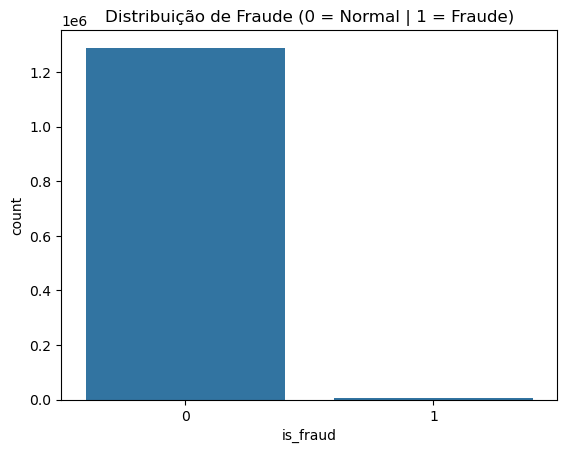


Insight: O dataset é EXTREMAMENTE desbalanceado (~0.5% de fraude). Precisaremos de técnicas como class_weight, SMOTE, undersampling ou focal loss.


In [10]:
# ======================== 3. ANÁLISE DO TARGET (is_fraud) ========================
print("=== DISTRIBUIÇÃO DO TARGET ===")
fraud_rate = df['is_fraud'].mean() * 100
print(f"Taxa de fraude: {fraud_rate:.4f}%")
print(df['is_fraud'].value_counts(normalize=True) * 100)

sns.countplot(data=df, x='is_fraud')
plt.title('Distribuição de Fraude (0 = Normal | 1 = Fraude)')
plt.show()

print("\nInsight: O dataset é EXTREMAMENTE desbalanceado (~0.5% de fraude). "
      "Precisaremos de técnicas como class_weight, SMOTE, undersampling ou focal loss.")

=== ESTATÍSTICAS DESCRITIVAS (numéricas) ===


,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


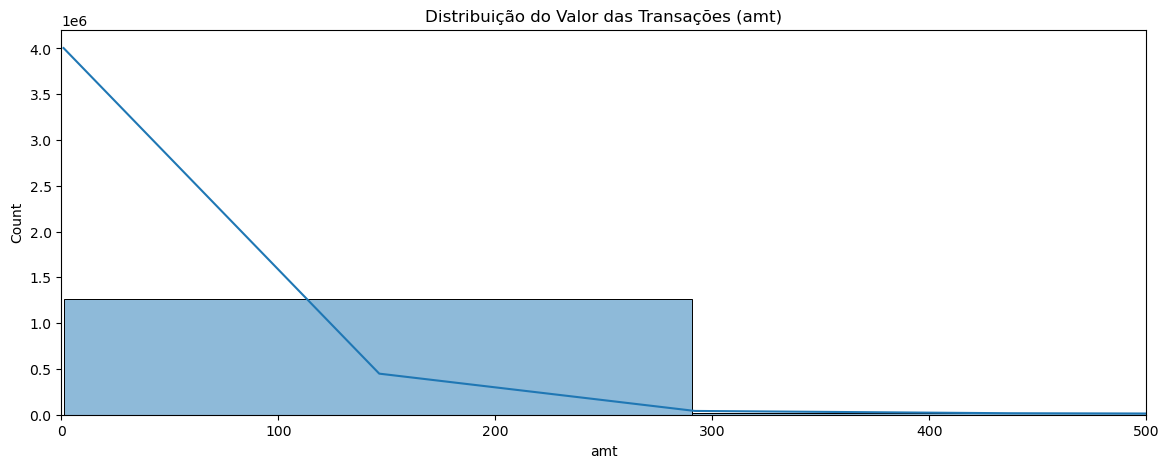

Insight: A maioria das transações é abaixo de $100. Fraudes tendem a ter valores maiores.


In [11]:
# ======================== 4. ANÁLISE NUMÉRICA ========================
print("=== ESTATÍSTICAS DESCRITIVAS (numéricas) ===")
display(df.describe())

# Distribuição do valor da transação (amt) - MUITO importante
plt.figure(figsize=(14,5))
sns.histplot(df['amt'], bins=100, kde=True)
plt.title('Distribuição do Valor das Transações (amt)')
plt.xlim(0, 500)
plt.show()

print("Insight: A maioria das transações é abaixo de $100. Fraudes tendem a ter valores maiores.")

In [12]:
# ======================== 5. ANÁLISE CATEGÓRICA ========================
cat_cols = ['category', 'gender', 'state', 'job']
for col in cat_cols:
    print(f"\n=== {col.upper()} - Top 10 ===")
    print(df[col].value_counts().head(10))
    
    # Taxa de fraude por categoria
    if col != 'job':  # job tem muitos valores
        fraud_by_cat = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False) * 100
        print(f"\nTaxa de fraude por {col} (%):")
        print(fraud_by_cat.head(10))


=== CATEGORY - Top 10 ===
category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
Name: count, dtype: int64

Taxa de fraude por category (%):
category
shopping_net     1.756149
misc_net         1.445795
grocery_pos      1.409761
shopping_pos     0.722538
gas_transport    0.469394
misc_pos         0.313853
grocery_net      0.294817
travel           0.286370
entertainment    0.247835
personal_care    0.242403
Name: is_fraud, dtype: float64

=== GENDER - Top 10 ===
gender
F    709863
M    586812
Name: count, dtype: int64

Taxa de fraude por gender (%):
gender
M    0.642625
F    0.526158
Name: is_fraud, dtype: float64

=== STATE - Top 10 ===
state
TX    94876
NY    83501
PA    79847
CA    56360
OH    46480
MI    46154
IL    43252
FL    42671
AL    40989
MO    38403
Name: count, dtype: int6

In [13]:
# ======================== 6. ENGENHARIA DE FEATURES INICIAL (para EDA) ========================
# 6.1 Converter datas
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# 6.2 Features temporais
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['month'] = df['trans_date_trans_time'].dt.month_name()

# 6.3 Idade do cliente
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# 6.4 Distância entre cliente e comerciante (Haversine simplificada)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # raio da Terra em km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

print("Features temporais, idade e distância criadas com sucesso!")

Features temporais, idade e distância criadas com sucesso!


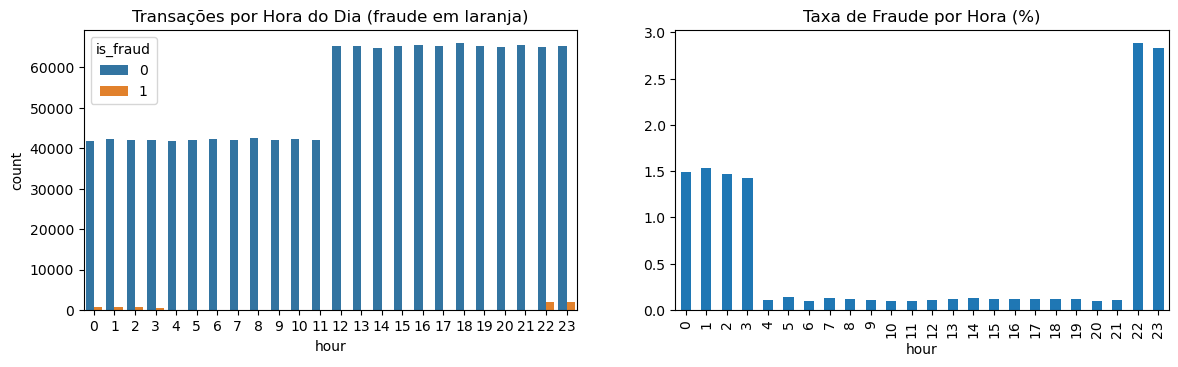

Insight: Fraudes são bem mais comuns entre 22h e 4h da manhã (horário noturno).


In [14]:
# ======================== 7. ANÁLISE TEMPORAL ========================
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
sns.countplot(data=df, x='hour', hue='is_fraud')
plt.title('Transações por Hora do Dia (fraude em laranja)')

plt.subplot(2,2,2)
fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
fraud_by_hour.plot(kind='bar')
plt.title('Taxa de Fraude por Hora (%)')
plt.show()

print("Insight: Fraudes são bem mais comuns entre 22h e 4h da manhã (horário noturno).")

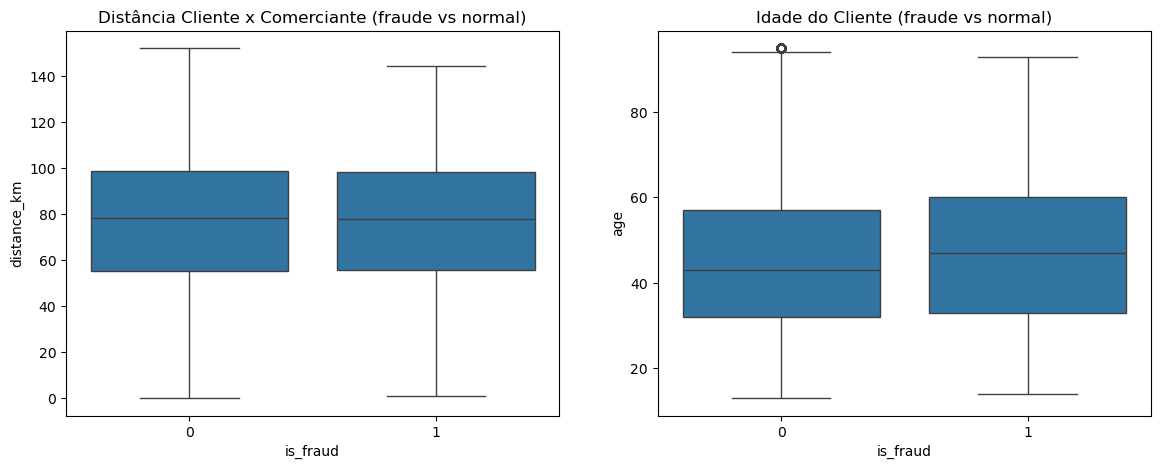

Insight: Fraudes ocorrem em distâncias maiores (comerciante distante) e em faixas etárias específicas.


In [15]:
# ======================== 8. ANÁLISE DE DISTÂNCIA E IDADE ========================
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x='is_fraud', y='distance_km')
plt.title('Distância Cliente x Comerciante (fraude vs normal)')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='is_fraud', y='age')
plt.title('Idade do Cliente (fraude vs normal)')
plt.show()

print("Insight: Fraudes ocorrem em distâncias maiores (comerciante distante) e em faixas etárias específicas.")

=== CATEGORIAS COM MAIOR TAXA DE FRAUDE ===
category
shopping_net     1.756149
misc_net         1.445795
grocery_pos      1.409761
shopping_pos     0.722538
gas_transport    0.469394
misc_pos         0.313853
grocery_net      0.294817
travel           0.286370
Name: is_fraud, dtype: float64


C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_3544\801002428.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_risk_categories.values * 100, y=high_risk_categories.index, palette='Reds_r')


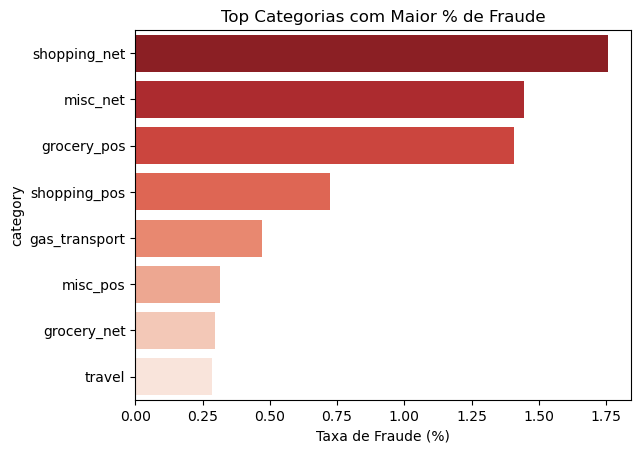

In [16]:
# ======================== 9. ANÁLISE DE CATEGORIAS DE ALTO RISCO ========================
high_risk_categories = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(8)
print("=== CATEGORIAS COM MAIOR TAXA DE FRAUDE ===")
print(high_risk_categories * 100)

sns.barplot(x=high_risk_categories.values * 100, y=high_risk_categories.index, palette='Reds_r')
plt.title('Top Categorias com Maior % de Fraude')
plt.xlabel('Taxa de Fraude (%)')
plt.show()

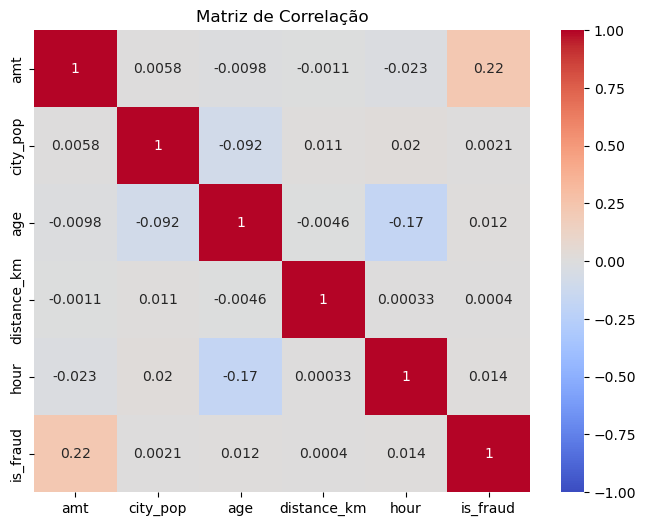

Insight: amt e distance_km são as features numéricas mais correlacionadas com fraude.


In [17]:
# ======================== 10. CORRELAÇÕES E HEATMAP ========================
num_cols = ['amt', 'city_pop', 'age', 'distance_km', 'hour', 'is_fraud']
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

print("Insight: amt e distance_km são as features numéricas mais correlacionadas com fraude.")

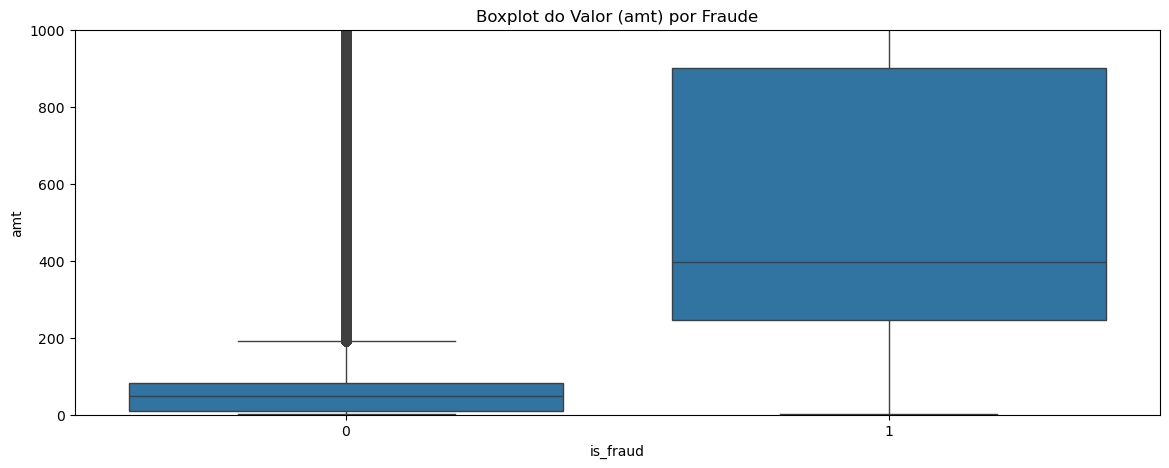

Insight: Fraudes têm valores médios e máximos bem maiores. Outliers em amt são candidatos a fraude.


In [18]:
# ======================== 11. OUTLIERS E VALORES EXTREMOS ========================
plt.figure(figsize=(14,5))
sns.boxplot(data=df, x='is_fraud', y='amt')
plt.ylim(0, 1000)
plt.title('Boxplot do Valor (amt) por Fraude')
plt.show()

print("Insight: Fraudes têm valores médios e máximos bem maiores. Outliers em amt são candidatos a fraude.")

In [19]:
# ======================== 12. SALVANDO INSIGHTS E GRÁFICOS ========================
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# Salvar alguns plots importantes
plt.savefig(output_dir / 'fraud_by_category.png')
plt.savefig(output_dir / 'fraud_by_hour.png')

print("\n✅ Análise completa finalizada!")
print("Gráficos salvos em ../outputs/")
print("\nPrincipais descobertas:")
print("• Taxa de fraude: ~0.5% (altamente desbalanceado)")
print("• Fraudes concentram-se em valores altos e distâncias grandes")
print("• Horário noturno (22h-4h) tem risco muito maior")
print("• Categorias de alto risco: shopping_net, grocery_pos, entertainment, etc.")
print("• Próximos passos: Feature Engineering avançado + tratamento de desbalanceamento")


✅ Análise completa finalizada!
Gráficos salvos em ../outputs/

Principais descobertas:
• Taxa de fraude: ~0.5% (altamente desbalanceado)
• Fraudes concentram-se em valores altos e distâncias grandes
• Horário noturno (22h-4h) tem risco muito maior
• Categorias de alto risco: shopping_net, grocery_pos, entertainment, etc.
• Próximos passos: Feature Engineering avançado + tratamento de desbalanceamento


<Figure size 640x480 with 0 Axes>